# S&P500 Trend Model
In this notebook I will pull several economic indicators to use as features in a machine learning model that will attempt to predict monthly S&P500 returns. Successfully predicting whether a given month will have either positive or negative return, I will then build an Algorithmic trading strategy to either buy or short the index using the SPY etf as a proxy.

In [1]:
#pip install setuptools

In [2]:
#pip install pandas_datareader

In [4]:
# Import libraries and dependencies

#!pip install yfinance
#!pip install pandas-datareader
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import pandas_datareader.data as web

%matplotlib inline

# Data Retrieval, Cleaning and Manipulation

In [5]:
# Setting up universal data cleaning functions for FRED Economic data
def get_and_clean_data(time_series_code, variable_name):
    start_date = '2000-01-01'
    end_date = '2025-03-17'
    df = web.DataReader(time_series_code, 'fred', start_date, end_date)
    df.columns.values[0] = variable_name
    return df

def pct_change(df,value, time_period):
    df[f'{value}_YoY'] = df[value].pct_change(time_period) * 100
    df[f'{value}_YoY'] = df[f'{value}_YoY'].replace(-np.inf, np.nan).dropna()
    return df

def set_date_to_month_end(df):
    df.index = df.index.to_period('M').to_timestamp('M')
    return df

def resample_monthly(df, variable_name):
    df_resampled = df[variable_name].resample('ME').sum()
    df_resampled = pd.DataFrame(df_resampled)
    return df_resampled

### Macro Indicators Processing Section

*Note: some of the features listed below here were not in the end added as features in the model.

#### US Real PCE Data (Feature 1 of 10)

In [6]:
# Clean PCE data: feature (1 of 10)
#clean_data(US_Real_PCE_data, "Real_PCE")
US_Real_PCE_data = get_and_clean_data("PCEC96", "Real_PCE")
pct_change(US_Real_PCE_data, "Real_PCE", 12)

# Changing date index to last day of the month
US_Real_PCE_data = set_date_to_month_end(US_Real_PCE_data)

# Drop Na's
US_Real_PCE_data = US_Real_PCE_data.dropna()
US_Real_PCE_data.head()

,Real_PCE,Real_PCE_YoY
DATE,,
2008-01-31,11333.2,1.361238
2008-02-29,11293.9,1.035050
2008-03-31,11322.1,1.174189
2008-04-30,11340.5,1.240905
2008-05-31,11361.6,1.280086


In [7]:
US_Real_PCE_data.tail()

,Real_PCE,Real_PCE_YoY
DATE,,
2024-10-31,16194.7,3.110893
2024-11-30,16267.2,3.126664
2024-12-31,16357.7,3.112078
2025-01-31,16257.6,2.814211
2025-02-28,16274.2,2.684115


#### US Initial Jobless Claims (Feature 2 of 10)

In [8]:
# Clean US Initial Claims data: feature (2 of 10)
#clean_data(US_Initial_Claims_data, "Initial_Claims")
US_Initial_Claims_data = get_and_clean_data("ICSA", "Initial_Claims")

# Resample Weekly data to Monthly
US_Initial_Claims_data_resampled = resample_monthly(US_Initial_Claims_data, "Initial_Claims")

# Calculate YoY change
pct_change(US_Initial_Claims_data_resampled, "Initial_Claims", 12)
US_Initial_Claims_data_resampled.tail()

,Initial_Claims,Initial_Claims_YoY
DATE,,
2024-11-30,1097000,25.802752
2024-12-31,889000,-14.271938
2025-01-31,854000,1.666667
2025-02-28,904000,7.236062
2025-03-31,672000,-37.488372


#### Capacity Utilization (Feature 3 of 10)

In [9]:
# Clean capacity utilization data: feature (3 of 10)
#clean_data(US_Cap_Util, "Capacity_Utilization")
US_Cap_Util = get_and_clean_data("TCU", "Capacity_Utilization")

# Calculate YoY Change
pct_change(US_Cap_Util, "Capacity_Utilization", 12)

# Changing date index to last day of the month
US_Cap_Util = set_date_to_month_end(US_Cap_Util)

US_Cap_Util.tail(10)

,Capacity_Utilization,Capacity_Utilization_YoY
DATE,,
2024-05-31,78.0627,-1.454773
2024-06-30,78.1993,-0.505746
2024-07-31,77.5681,-1.795128
2024-08-31,77.8658,-1.282371
2024-09-30,77.4591,-1.861312
2024-10-31,77.1206,-1.469891
2024-11-30,76.8424,-2.008233
2024-12-31,77.6044,-0.687216
2025-01-31,77.7090,0.666498


#### US Personal Savings Rate (Feature 4 of 10)

In [10]:
# Clean US_Personal_Savings_Rate data: feature (4 of 10)

#clean_data(US_Personal_Savings_Rate, "US_Personal_Savings_Rate_%_of_DPI")
US_Personal_Savings_Rate = get_and_clean_data("PSAVERT", "US_Personal_Savings_Rate_%_of_DPI")

# Calculate YoY Change
pct_change(US_Personal_Savings_Rate, "US_Personal_Savings_Rate_%_of_DPI", 12)

# Changing date index to last day of the month
US_Personal_Savings_Rate_df = set_date_to_month_end(US_Personal_Savings_Rate)

US_Personal_Savings_Rate_df.tail(20)

,US_Personal_Savings_Rate_%_of_DPI,US_Personal_Savings_Rate_%_of_DPI_YoY
DATE,,
2023-07-31,4.6,48.387097
2023-08-31,4.7,51.612903
2023-09-30,4.4,41.935484
2023-10-31,4.5,40.625000
2023-11-30,4.6,35.294118
2023-12-31,4.4,18.918919
2024-01-31,5.5,30.952381
2024-02-29,5.4,17.391304
2024-03-31,5.2,-1.886792


#### US Real Disposable Income (Feature 5 of 10)

In [11]:
# Clean US_Real_Disposable_Income data: feature (5 of 10)

#clean_data(US_Real_Disposable_Income, "US_Real_DPI")
US_Real_Disposable_Income = get_and_clean_data("DSPIC96", "US_Real_DPI")

# Calculate YoY Change
pct_change(US_Real_Disposable_Income, "US_Real_DPI", 12)

# Changing date index to last day of the month
US_Real_Disposable_Income_df = set_date_to_month_end(US_Real_Disposable_Income)

US_Real_Disposable_Income_df.tail(10)

,US_Real_DPI,US_Real_DPI_YoY
DATE,,
2024-05-31,17511.1,2.753214
2024-06-30,17515.6,2.728984
2024-07-31,17505.0,2.598818
2024-08-31,17494.6,2.392630
2024-09-30,17519.6,2.447211
2024-10-31,17568.5,2.423511
2024-11-30,17592.4,2.106864
2024-12-31,17605.8,1.959762
2025-01-31,17661.4,1.349692


#### US M2 Money Stock (Feature 6 of 10)

In [12]:
# Clean M2 Money stock data: feature (6 of 10)
#clean_data(US_M2_stock, "M2")
US_M2_stock = get_and_clean_data("M2SL", "M2")

# Resample Weekly data to Monthly (not using resampling function here as we don't want to sum weekly figures, we just want the last figure)
M2_stock_resampled = US_M2_stock.resample('ME').last()

# Calculate YoY change
pct_change(M2_stock_resampled, "M2", 12)

M2_stock_resampled.tail(13)

,M2,M2_YoY
DATE,,
2024-02-29,20861.6,-1.524692
2024-03-31,20901.5,0.120711
2024-04-30,20932.9,0.979262
2024-05-31,20997.1,0.940802
2024-06-30,21065.5,1.361235
2024-07-31,21098.2,1.568916
2024-08-31,21185.7,2.115015
2024-09-30,21272.2,2.665058
2024-10-31,21335.5,3.133323


#### US PCE Inflation Rate (Feature 7 of 10)

In [13]:
# Clean PCE data: feature (7 of 10)
#clean_data(US_PCE_data, "Inflation Rate")
US_PCE_data = get_and_clean_data("PCETRIM12M159SFRBDAL", "Inflation Rate")

# Changing date index to last day of the month
US_PCE_data = set_date_to_month_end(US_PCE_data)
US_PCE_data.isnull().sum()

Inflation Rate    0
dtype: int64

#### US 10-2 YR Treasury Yield Spread (Feature 8 of 10)

In [14]:
# Clean Yield Curve data: feature (8 of 10)
#clean_data(US_yield_curve, "10yr minus 2yr yield")
US_yield_curve = get_and_clean_data("T10Y2Y", "10yr minus 2yr yield")

# Construct the dependent variable where if monthly return is greater than 0, then 1, else, 0.
US_yield_curve.loc[:, 'Inversion Signal'] = (US_yield_curve['10yr minus 2yr yield'] <= 0)

# Clean Yield Curve data 
US_yield_curve = US_yield_curve.resample('ME').agg({'10yr minus 2yr yield':'last', 'Inversion Signal':'any'})

US_yield_curve.tail(20)

,10yr minus 2yr yield,Inversion Signal
DATE,,
2023-08-31,-0.76,True
2023-09-30,-0.44,True
2023-10-31,-0.19,True
2023-11-30,-0.36,True
2023-12-31,-0.35,True
2024-01-31,-0.28,True
2024-02-29,-0.39,True
2024-03-31,-0.39,True
2024-04-30,-0.35,True


In [15]:
# Final US yield curve data
US_yield_curve["Inversion Signal"] = US_yield_curve["Inversion Signal"].astype(int)

In [16]:
US_yield_curve["Inversion Signal"].value_counts()

Inversion Signal
0    245
1     58
Name: count, dtype: int64

In [17]:
US_yield_curve.tail(20)

,10yr minus 2yr yield,Inversion Signal
DATE,,
2023-08-31,-0.76,1
2023-09-30,-0.44,1
2023-10-31,-0.19,1
2023-11-30,-0.36,1
2023-12-31,-0.35,1
2024-01-31,-0.28,1
2024-02-29,-0.39,1
2024-03-31,-0.39,1
2024-04-30,-0.35,1


#### VIX Index - Volatility Signal (Feature 9 of 10)

In [18]:
#Download stock data function:
def download_data(tickers, start_date):
    stock_data = yf.download(tickers,start=start_date)
    stock_data = stock_data.drop(columns=["High", "Low", "Open", "Volume"])
    stock_data["Close"] = stock_data['Close'].astype(float)
    stock_data = stock_data.dropna()
    return stock_data

In [19]:
# Download VIX data
VIX_df = download_data(['^VIX'], "1980-01-01")
VIX_df.head()

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,^VIX
Date,
1990-01-02,17.240000
1990-01-03,18.190001
1990-01-04,19.219999
1990-01-05,20.110001
1990-01-08,20.260000


In [20]:
# Clean Vix DF data and calculate monthly returns
VIX_resampled = VIX_df.resample('ME').last()
VIX_resampled["VIX Monthly Return"] = VIX_resampled['Close'].pct_change() * 100
VIX_resampled = VIX_resampled.dropna()
VIX_resampled.loc[:, "Vol Signal"] = (VIX_resampled['Close'] < VIX_resampled['Close'].shift(1)).astype(int)
VIX_resampled.tail(20)

Price,Close,VIX Monthly Return,Vol Signal
Ticker,^VIX,,
Date,,,
2023-09-30,17.520000,29.108333,0
2023-10-31,18.139999,3.538807,0
2023-11-30,12.920000,-28.776182,1
2023-12-31,12.450000,-3.637773,1
2024-01-31,14.350000,15.261049,0
2024-02-29,13.400000,-6.620214,1
2024-03-31,13.010000,-2.910443,1
2024-04-30,15.650000,20.292078,0


#### Industrials Basket of Stocks (Feature 10 of 10)

In [21]:
# Download Industrials Stock data
industrials_df = download_data(['FDX','UNP','HON','LMT','MMM'], "1980-01-01")
industrials_df.head()

[*********************100%***********************]  5 of 5 completed


Price          Close                                        
Ticker           FDX       HON       LMT       MMM       UNP
Date                                                        
1980-01-02  2.292703  2.126051  1.127033  1.199687  1.017251
1980-01-03  2.343652  2.081293  1.199062  1.151215  1.003074
1980-01-04  2.483762  2.103671  1.288037  1.151215  1.020796
1980-01-07  2.509236  2.098077  1.360066  1.157274  1.015479
1980-01-08  2.598397  2.148431  1.482938  1.199687  0.978262

In [22]:
# Clean Industrials Stock data and calculate monthly returns
industrials_resampled = industrials_df.resample('ME').last()

# This drops the upper 'Close' level in the dataframe
industrials_resampled = industrials_resampled.droplevel(0, axis=1)

# This is a function to calculate monthly percentage returns, which we will then apply to each stock
def monthly_return(df):
    df = df.pct_change() * 100
    df = df.dropna()
    return df

industrials_resampled = industrials_resampled.apply(monthly_return)
# Calculate an average return for all stocks
industrials_resampled["Average Industrials Stock Return"] = industrials_resampled.mean(axis=1)
industrials_resampled.tail(20)

Ticker,FDX,HON,LMT,MMM,UNP,Average Industrials Stock Return
Date,,,,,,
2023-09-30,1.995842,-1.702657,-8.785547,-12.233992,-7.680103,-5.681291
2023-10-31,-9.368867,-0.801132,11.169794,-2.851968,1.954521,0.020469
2023-11-30,7.800915,7.537289,-0.808963,10.642142,8.506340,6.735545
2023-12-31,-1.801721,7.038590,1.221600,10.346218,9.645441,5.290026
2024-01-31,-4.617147,-3.552530,-5.257684,-13.693734,-0.688061,-5.561831
2024-02-29,3.182891,-1.205221,0.459223,-0.741824,4.537689,1.246552
2024-03-31,16.964410,3.280833,6.218481,15.143296,-3.058858,7.709633
2024-04-30,-9.650030,-6.099886,2.211614,8.820550,-3.566055,-1.656761
2024-05-31,-2.987245,5.463879,1.163625,4.481898,-1.270096,1.370412


#### Pulling USD monthly returns

In [23]:
# Download USD returns
USD_df = download_data(['DX-Y.NYB'], "1980-01-01")
USD_df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,DX-Y.NYB
Date,
1980-01-02,85.320000
1980-01-03,85.260002
1980-01-04,85.230003
1980-01-07,84.790001
1980-01-08,85.070000


In [24]:
# Clean USD data and calculate monthly returns
USD_resampled = USD_df.resample('ME').last()
USD_resampled["USD Monthly Return"] = USD_resampled['Close'].pct_change() * 100
USD_resampled = USD_resampled.dropna()
USD_resampled = USD_resampled.set_axis(['Close DX-Y', 'Monthly Return USD'], axis='columns')
USD_resampled.tail(20)

,Close DX-Y,Monthly Return USD
Date,,
2023-09-30,106.169998,2.460910
2023-10-31,106.660004,0.461529
2023-11-30,103.500000,-2.962688
2023-12-31,101.330002,-2.096617
2024-01-31,103.269997,1.914532
2024-02-29,104.160004,0.861825
2024-03-31,104.550003,0.374423
2024-04-30,106.220001,1.597320
2024-05-31,104.669998,-1.459238


#### Pulling JPY vs EUR monthly returns

In [25]:
# Pull JPY prices
JPY_df = download_data(['JPYEUR=X'], "1980-01-01")
JPY_df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,JPYEUR=X
Date,
2005-09-16,0.00734
2005-09-19,0.00739
2005-09-20,0.00737
2005-09-22,0.00737
2005-09-23,0.00738


In [26]:
JPY_df.tail()

Price,Close
Ticker,JPYEUR=X
Date,
2025-04-07,0.006257
2025-04-08,0.006196
2025-04-09,0.006242
2025-04-10,0.006194
2025-04-11,0.006132


#### S&P500 Price and Returns
SPY etf is used as proxy for SP500 returns. Monthly SPY returns will be our y-variable for our model and will be used as our benchmark for for algorithmic trading strategy.

In [27]:
# Download SPY (SP500) Prices
SP500_df = download_data(["SPY"], "1993-01-01")
SP500_df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,SPY
Date,
1993-01-29,24.452509
1993-02-01,24.626436
1993-02-02,24.678617
1993-02-03,24.939478
1993-02-04,25.043831


In [28]:
# Clean SPY data and calculate monthly returns
SPY_resampled = SP500_df.resample('ME').last()
SPY_resampled["Monthly Return"] = SPY_resampled['Close'].pct_change() * 100
SPY_resampled = SPY_resampled.dropna()
SPY_resampled.tail()

Price,Close,Monthly Return
Ticker,SPY,
Date,,
2024-12-31,584.322266,-2.406001
2025-01-31,600.015015,2.685633
2025-02-28,592.397949,-1.269479
2025-03-31,559.390015,-5.571919
2025-04-30,533.940002,-4.549601


In [29]:

SPY_resampled = SPY_resampled.set_axis(['Close SPY', 'Monthly Return SPY'], axis='columns')
SPY_resampled.tail()

,Close SPY,Monthly Return SPY
Date,,
2024-12-31,584.322266,-2.406001
2025-01-31,600.015015,2.685633
2025-02-28,592.397949,-1.269479
2025-03-31,559.390015,-5.571919
2025-04-30,533.940002,-4.549601


### Concating DataFrames

In [30]:
# Not including Real PCE data for now, as data only goes back to 2003
master_df = pd.concat([SPY_resampled,
                       US_Initial_Claims_data_resampled, 
                       US_Cap_Util,
                       US_Real_Disposable_Income,
                       US_Personal_Savings_Rate, 
                       M2_stock_resampled, 
                       US_PCE_data, 
                       US_yield_curve, 
                       industrials_resampled["Average Industrials Stock Return"],
                       VIX_resampled["Vol Signal"], 
                       USD_resampled], axis="columns", join='inner')
master_df.head()

,Close SPY,Monthly Return SPY,Initial_Claims,Initial_Claims_YoY,Capacity_Utilization,Capacity_Utilization_YoY,US_Real_DPI,US_Real_DPI_YoY,US_Personal_Savings_Rate_%_of_DPI,US_Personal_Savings_Rate_%_of_DPI_YoY,M2,M2_YoY,Inflation Rate,10yr minus 2yr yield,Inversion Signal,Average Industrials Stock Return,Vol Signal,Close DX-Y,Monthly Return USD
2000-01-31,88.681839,-4.978682,1442000,NaN,82.0932,NaN,9799.9,NaN,4.5,NaN,4667.6,NaN,2.00,0.07,0,-9.558205,0,105.129997,3.200152
2000-02-29,87.331497,-1.522681,1175000,NaN,82.0943,NaN,9837.9,NaN,4.0,NaN,4680.9,NaN,2.12,-0.11,1,-5.510447,1,105.919998,0.751451
2000-03-31,95.795174,9.691436,1099000,NaN,82.1340,NaN,9864.0,NaN,3.8,NaN,4711.7,NaN,2.24,-0.47,1,8.497185,0,105.440002,-0.453168
2000-04-30,92.430870,-3.511976,1358000,NaN,82.3741,NaN,9913.7,NaN,4.3,NaN,4767.8,NaN,2.18,-0.45,1,6.116220,0,110.139999,4.457508
2000-05-31,90.977600,-1.572278,1129000,NaN,82.3350,NaN,9954.5,NaN,4.3,NaN,4755.7,NaN,2.22,-0.40,1,-1.519256,1,108.739998,-1.271111


### Building the Model

In [31]:
# Set up an industrials stock signal, where 1 is a sell signal = S&P500 outperforms industrials, and 0 is a buy signal 
master_df.loc[:, 'Industrials Stock Signal'] = (master_df['Monthly Return SPY'] > master_df["Average Industrials Stock Return"]).astype(int)
master_df.head()

,Close SPY,Monthly Return SPY,Initial_Claims,Initial_Claims_YoY,Capacity_Utilization,Capacity_Utilization_YoY,US_Real_DPI,US_Real_DPI_YoY,US_Personal_Savings_Rate_%_of_DPI,US_Personal_Savings_Rate_%_of_DPI_YoY,M2,M2_YoY,Inflation Rate,10yr minus 2yr yield,Inversion Signal,Average Industrials Stock Return,Vol Signal,Close DX-Y,Monthly Return USD,Industrials Stock Signal
2000-01-31,88.681839,-4.978682,1442000,NaN,82.0932,NaN,9799.9,NaN,4.5,NaN,4667.6,NaN,2.00,0.07,0,-9.558205,0,105.129997,3.200152,1
2000-02-29,87.331497,-1.522681,1175000,NaN,82.0943,NaN,9837.9,NaN,4.0,NaN,4680.9,NaN,2.12,-0.11,1,-5.510447,1,105.919998,0.751451,1
2000-03-31,95.795174,9.691436,1099000,NaN,82.1340,NaN,9864.0,NaN,3.8,NaN,4711.7,NaN,2.24,-0.47,1,8.497185,0,105.440002,-0.453168,1
2000-04-30,92.430870,-3.511976,1358000,NaN,82.3741,NaN,9913.7,NaN,4.3,NaN,4767.8,NaN,2.18,-0.45,1,6.116220,0,110.139999,4.457508,0
2000-05-31,90.977600,-1.572278,1129000,NaN,82.3350,NaN,9954.5,NaN,4.3,NaN,4755.7,NaN,2.22,-0.40,1,-1.519256,1,108.739998,-1.271111,0


In [32]:
# Set x variable list of features
x_var_list = ['Initial_Claims_YoY', 
              'Capacity_Utilization_YoY', 
              'US_Real_DPI_YoY', 
              'US_Personal_Savings_Rate_%_of_DPI_YoY', #
              'M2_YoY', 
              'Inflation Rate', 
              'Inversion Signal', 
              'Industrials Stock Signal', #
              'Monthly Return USD', #
              'Vol Signal'
             ]

# Filter by x-variable list
master_df[x_var_list].tail()


,Initial_Claims_YoY,Capacity_Utilization_YoY,US_Real_DPI_YoY,US_Personal_Savings_Rate_%_of_DPI_YoY,M2_YoY,Inflation Rate,Inversion Signal,Industrials Stock Signal,Monthly Return USD,Vol Signal
2024-10-31,12.366231,-1.469891,2.423511,-11.111111,3.133323,2.74,0,1,3.175238,0
2024-11-30,25.802752,-2.008233,2.106864,-19.565217,3.660952,2.76,0,0,1.692628,1
2024-12-31,-14.271938,-0.687216,1.959762,-25.000000,3.809887,2.84,0,1,2.600719,0
2025-01-31,1.666667,0.666498,1.349692,-21.818182,3.869390,2.58,0,0,-0.110605,1
2025-02-28,7.236062,0.149864,1.799064,-14.814815,3.879856,2.57,0,0,-0.701303,0


In [33]:
# Shift DataFrame values by 1 = this will shift data points forward one month so that we are using previous months data to predict current month y variable.
master_df[x_var_list] = master_df[x_var_list].shift(1)
master_df[x_var_list].tail()

,Initial_Claims_YoY,Capacity_Utilization_YoY,US_Real_DPI_YoY,US_Personal_Savings_Rate_%_of_DPI_YoY,M2_YoY,Inflation Rate,Inversion Signal,Industrials Stock Signal,Monthly Return USD,Vol Signal
2024-10-31,-17.808219,-1.861312,2.447211,-13.636364,2.665058,2.66,1.0,1.0,-0.904620,0.0
2024-11-30,12.366231,-1.469891,2.423511,-11.111111,3.133323,2.74,0.0,1.0,3.175238,0.0
2024-12-31,25.802752,-2.008233,2.106864,-19.565217,3.660952,2.76,0.0,0.0,1.692628,1.0
2025-01-31,-14.271938,-0.687216,1.959762,-25.000000,3.809887,2.84,0.0,1.0,2.600719,0.0
2025-02-28,1.666667,0.666498,1.349692,-21.818182,3.869390,2.58,0.0,0.0,-0.110605,1.0


In [34]:
# Drop NAs and replace positive/negative infinity values
master_df.dropna(subset=x_var_list, inplace=True)
master_df = master_df.replace([np.inf, -np.inf], np.nan)
master_df.head()

,Close SPY,Monthly Return SPY,Initial_Claims,Initial_Claims_YoY,Capacity_Utilization,Capacity_Utilization_YoY,US_Real_DPI,US_Real_DPI_YoY,US_Personal_Savings_Rate_%_of_DPI,US_Personal_Savings_Rate_%_of_DPI_YoY,M2,M2_YoY,Inflation Rate,10yr minus 2yr yield,Inversion Signal,Average Industrials Stock Return,Vol Signal,Close DX-Y,Monthly Return USD,Industrials Stock Signal
2001-02-28,79.589493,-9.538744,1485000,-5.686546,78.5159,-3.412828,10223.4,4.202084,4.6,0.000000,5017.1,6.658668,2.52,0.51,0.0,0.727675,1.0,112.010002,0.876231,1.0
2001-03-31,75.129501,-5.603744,1936000,26.382979,78.0741,-4.358890,10254.4,3.918519,4.9,15.000000,5074.9,7.182379,2.54,0.75,0.0,-4.102456,0.0,117.370003,1.348177,0.0
2001-04-30,81.548538,8.543963,1587000,76.160146,77.5610,-4.943020,10233.1,3.957826,4.8,28.947368,5139.2,7.708470,2.50,1.05,0.0,7.009111,0.0,115.849998,4.785287,0.0
2001-05-31,81.091454,-0.560506,1578000,16.863034,76.9249,-5.842977,10214.7,3.221804,4.3,11.627907,5137.3,7.789756,2.59,1.21,0.0,0.906676,1.0,119.070000,-1.295053,1.0
2001-06-30,79.159088,-2.382946,1986000,39.769708,76.3013,-6.570839,10218.1,2.613893,4.2,0.000000,5180.3,8.024055,2.59,1.17,0.0,-7.715313,1.0,119.430000,2.779457,0.0


In [35]:
# Set up new dataframe with just x-features and y variable
new_df_list = ['Monthly Return SPY',
               'Initial_Claims_YoY', 
               'Capacity_Utilization_YoY', 
               'US_Real_DPI_YoY', 
               'US_Personal_Savings_Rate_%_of_DPI_YoY', #
               'M2_YoY', 
               'Inflation Rate', 
               'Inversion Signal', 
               'Industrials Stock Signal', #
               'Monthly Return USD',#
               'Vol Signal'
              ]
new_df = master_df[new_df_list]
new_df.tail()

,Monthly Return SPY,Initial_Claims_YoY,Capacity_Utilization_YoY,US_Real_DPI_YoY,US_Personal_Savings_Rate_%_of_DPI_YoY,M2_YoY,Inflation Rate,Inversion Signal,Industrials Stock Signal,Monthly Return USD,Vol Signal
2024-10-31,-0.892360,-17.808219,-1.861312,2.447211,-13.636364,2.665058,2.66,1.0,1.0,-0.904620,0.0
2024-11-30,5.963339,12.366231,-1.469891,2.423511,-11.111111,3.133323,2.74,0.0,1.0,3.175238,0.0
2024-12-31,-2.406001,25.802752,-2.008233,2.106864,-19.565217,3.660952,2.76,0.0,0.0,1.692628,1.0
2025-01-31,2.685633,-14.271938,-0.687216,1.959762,-25.000000,3.809887,2.84,0.0,1.0,2.600719,0.0
2025-02-28,-1.269479,1.666667,0.666498,1.349692,-21.818182,3.869390,2.58,0.0,0.0,-0.110605,1.0


In [36]:
# Construct the dependent variable where if monthly return is greater than 0, then 1, else, 0.
new_df.loc[:, 'Monthly Return SPY'] = (new_df['Monthly Return SPY'] > 0).astype(int)
new_df.tail()

,Monthly Return SPY,Initial_Claims_YoY,Capacity_Utilization_YoY,US_Real_DPI_YoY,US_Personal_Savings_Rate_%_of_DPI_YoY,M2_YoY,Inflation Rate,Inversion Signal,Industrials Stock Signal,Monthly Return USD,Vol Signal
2024-10-31,0.0,-17.808219,-1.861312,2.447211,-13.636364,2.665058,2.66,1.0,1.0,-0.904620,0.0
2024-11-30,1.0,12.366231,-1.469891,2.423511,-11.111111,3.133323,2.74,0.0,1.0,3.175238,0.0
2024-12-31,0.0,25.802752,-2.008233,2.106864,-19.565217,3.660952,2.76,0.0,0.0,1.692628,1.0
2025-01-31,1.0,-14.271938,-0.687216,1.959762,-25.000000,3.809887,2.84,0.0,1.0,2.600719,0.0
2025-02-28,0.0,1.666667,0.666498,1.349692,-21.818182,3.869390,2.58,0.0,0.0,-0.110605,1.0


In [37]:
new_df['Monthly Return SPY'].value_counts()

Monthly Return SPY
1.0    186
0.0    103
Name: count, dtype: int64

#### Split data into training and test sets

In [38]:
# Calculate the cutoff index for a 70/30 split
cutoff_index = int(0.7 * len(new_df))

In [39]:
# Split the data frame and get the start and end dates for training and testing sets
training_start = new_df.index.min().strftime('%Y-%m-%d')
training_end = new_df.iloc[cutoff_index].name.strftime('%Y-%m-%d')
testing_start = new_df.iloc[cutoff_index + 1].name.strftime('%Y-%m-%d')
testing_end = new_df.index.max().strftime('%Y-%m-%d')

# Print the start and end dates for training and testing
print(f"Training Start: {training_start}, End: {training_end}")
print(f"Testing Start: {testing_start}, End: {testing_end}")

Training Start: 2001-02-28, End: 2017-12-31
Testing Start: 2018-01-31, End: 2025-02-28


In [40]:
# Construct the x train and y train datasets
X_train = new_df.iloc[:cutoff_index][x_var_list]
y_train = new_df.iloc[:cutoff_index]['Monthly Return SPY']


In [41]:
# Construct the x test and y test datasets
X_test = new_df.iloc[cutoff_index:][x_var_list]
y_test = new_df.iloc[cutoff_index:]['Monthly Return SPY']

y_test.tail()

2024-10-31    0.0
2024-11-30    1.0
2024-12-31    0.0
2025-01-31    1.0
2025-02-28    0.0
Freq: ME, Name: Monthly Return SPY, dtype: float64

#### Scale the data

In [42]:
# Scaling data
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_scaler = scaler.fit(X_train)

X_train_scaled = X_scaler.transform(X_train)
X_test_scaled = X_scaler.transform(X_test)


In [43]:
X_train_scaled

array([[0.20603482, 0.4787473 , 0.84840545, ..., 1.        , 0.49984469,
        1.        ],
       [0.42411306, 0.44332895, 0.82098303, ..., 0.        , 0.53404316,
        0.        ],
       [0.76260629, 0.42146047, 0.82478428, ..., 0.        , 0.78310539,
        0.        ],
       ...,
       [0.20405813, 0.65733213, 0.78420383, ..., 0.        , 0.42152389,
        0.        ],
       [0.48534653, 0.67062784, 0.78022483, ..., 0.        , 0.46841057,
        1.        ],
       [0.07988392, 0.72065506, 0.79067319, ..., 1.        , 0.55079005,
        0.        ]])

### Random Forest Model

In [44]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification

In [45]:
# Fit a SKLearn RF model using just the training set (X_train, Y_train):
model = RandomForestClassifier(n_estimators=30, max_depth=4, random_state=0)
model.fit(X_train_scaled, y_train)

# Make predictions of y values from the x test dataset
predictions = model.predict(X_test_scaled)

# Assemble actual y data (Y_test) with predicted y data into two columns in a dataframe to compare:
Results = y_test.to_frame()
Results["Random Forest Predicted Value"] = predictions
Results

,Monthly Return SPY,Random Forest Predicted Value
2017-12-31,1.0,1.0
2018-01-31,1.0,1.0
2018-02-28,0.0,1.0
2018-03-31,0.0,1.0
2018-04-30,1.0,1.0
...,...,...
2024-10-31,0.0,1.0
2024-11-30,1.0,1.0
2024-12-31,0.0,0.0
2025-01-31,1.0,1.0


In [46]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Function to print a confusion matrix:
def predictions_to_confusion_matrix(y_test, predictions, model_title):
    
    cm = confusion_matrix(y_test, predictions)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                             display_labels=['Negative', 'Positive'])
    disp.plot(cmap='Blues')
    disp.ax_.set_title(model_title)
    plt.xticks(rotation=45)

    plt.show()
    

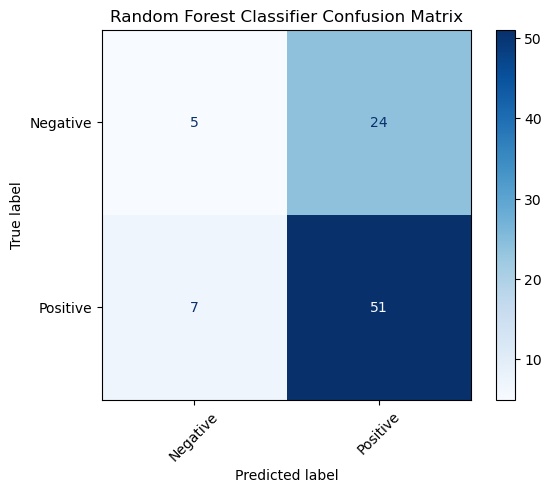

In [47]:
predictions_to_confusion_matrix(y_test, predictions, "Random Forest Classifier Confusion Matrix")

In [48]:
print("Test set accuracy: {:.2f}".format(model.score(X_test_scaled, y_test)))

Test set accuracy: 0.64


In [49]:
print("Test set predictions:", predictions)

Test set predictions: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 1. 1. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1.]


In [50]:
# List the features sorted in descending order by feature importance
important_features = model.feature_importances_

sorted(zip(model.feature_importances_, new_df[x_var_list]), reverse=True)

[(0.1857411375557791, 'Capacity_Utilization_YoY'),
 (0.17430473440210925, 'US_Real_DPI_YoY'),
 (0.15733142936631286, 'Inflation Rate'),
 (0.13101556375678794, 'M2_YoY'),
 (0.12713351502772918, 'US_Personal_Savings_Rate_%_of_DPI_YoY'),
 (0.09308106212829644, 'Initial_Claims_YoY'),
 (0.09115131842387726, 'Monthly Return USD'),
 (0.019756945342999058, 'Inversion Signal'),
 (0.011262424758509979, 'Industrials Stock Signal'),
 (0.009221869237599094, 'Vol Signal')]

In [51]:
importances_df = (pd.DataFrame(sorted(zip(model.feature_importances_, new_df[x_var_list]), reverse=True),
                  columns=['Feature Importances', 'Feature'])
        .set_index('Feature')
        .sort_values(by='Feature Importances'))

importances_df.plot(kind='barh', color='lightgreen', title='Features Importances', legend=False)

<Axes: title={'center': 'Features Importances'}, ylabel='Feature'>

In [52]:
# Print the imbalanced classification report
from imblearn.metrics import classification_report_imbalanced
print(classification_report_imbalanced(y_test, predictions))

                   pre       rec       spe        f1       geo       iba       sup

        0.0       0.42      0.17      0.88      0.24      0.39      0.14        29
        1.0       0.68      0.88      0.17      0.77      0.39      0.16        58

avg / total       0.59      0.64      0.41      0.59      0.39      0.16        87



In [53]:
## The range of values of MCC lie between -1 to +1.
#A model with a score of +1 is a perfect model and -1 is a poor model.
#Similarly to F1 score (Fi score considers TP, FP FN- does not take into account true negative.
#So F1 score is very sensitive to what is called negative but MCC is not
#so MCC actually gives you a better idea of what is going on in your data)

from sklearn.metrics import matthews_corrcoef
matthews_corrcoef(y_test, predictions)


0.07071067811865475

In order to get a more parsimonious model, we will try to find an optimal subset of features employed in the model using RFECV: Recursive feature elimination with cross-validation. This algorithm attempts to find the optimal number of features, as well as the optimal features for the model.

In [54]:
from sklearn.feature_selection import RFECV

selector = RFECV(estimator=model, step=1, cv=5, scoring='accuracy', verbose=1)
selector = selector.fit(X_train_scaled, y_train)
selector.ranking_

Fitting estimator with 10 features.
Fitting estimator with 9 features.
Fitting estimator with 8 features.
Fitting estimator with 7 features.
Fitting estimator with 6 features.
Fitting estimator with 5 features.
Fitting estimator with 4 features.
Fitting estimator with 3 features.
Fitting estimator with 2 features.
Fitting estimator with 10 features.
Fitting estimator with 9 features.
Fitting estimator with 8 features.
Fitting estimator with 7 features.
Fitting estimator with 6 features.
Fitting estimator with 5 features.
Fitting estimator with 4 features.
Fitting estimator with 3 features.
Fitting estimator with 2 features.
Fitting estimator with 10 features.
Fitting estimator with 9 features.
Fitting estimator with 8 features.
Fitting estimator with 7 features.
Fitting estimator with 6 features.
Fitting estimator with 5 features.
Fitting estimator with 4 features.
Fitting estimator with 3 features.
Fitting estimator with 2 features.
Fitting estimator with 10 features.
Fitting estimato

array([1, 1, 1, 1, 1, 1, 1, 2, 1, 3])

This gives the vector for choosing the columns.

In [55]:
selected_rfc = selector.get_support()
print(selected_rfc)

[ True  True  True  True  True  True  True False  True False]


In [56]:
model = RandomForestClassifier(n_estimators=30, max_depth=4, random_state=0)
model.fit(X_train_scaled[:,selected_rfc], y_train)

# Make predictions of y values from the x test dataset
predictions = model.predict(X_test_scaled[:,selected_rfc])

# Assemble actual y data (Y_test) with predicted y data into two columns in a dataframe to compare:
Results = y_test.to_frame()
Results["Random Forest Predicted Value"] = predictions
Results

,Monthly Return SPY,Random Forest Predicted Value
2017-12-31,1.0,1.0
2018-01-31,1.0,1.0
2018-02-28,0.0,1.0
2018-03-31,0.0,1.0
2018-04-30,1.0,1.0
...,...,...
2024-10-31,0.0,1.0
2024-11-30,1.0,1.0
2024-12-31,0.0,0.0
2025-01-31,1.0,1.0


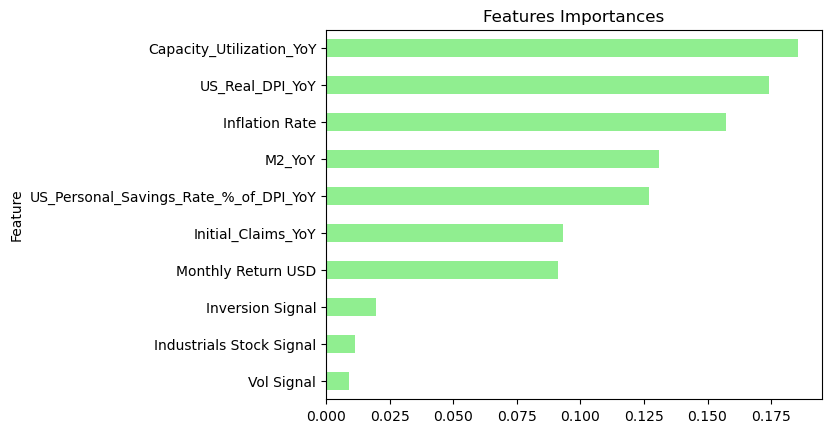

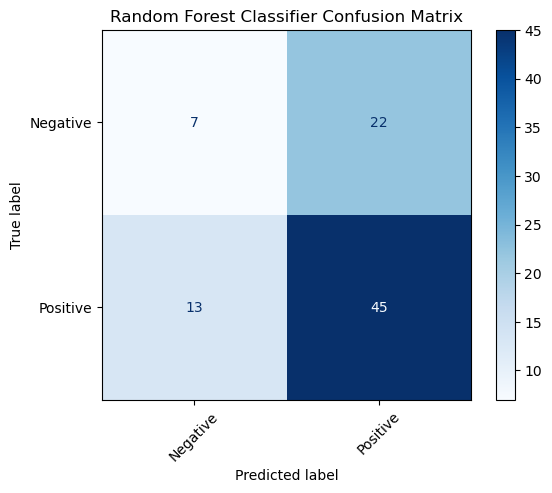

In [57]:
predictions_to_confusion_matrix(y_test, predictions, "Random Forest Classifier Confusion Matrix")

In [58]:
importances_df = (pd.DataFrame(sorted(zip(model.feature_importances_, new_df), reverse=True),
                  columns=['Feature Importances', 'Feature'])
        .set_index('Feature')
        .sort_values(by='Feature Importances'))

importances_df.plot(kind='barh', color='lightgreen', title='Features Importances', legend=False)

<Axes: title={'center': 'Features Importances'}, ylabel='Feature'>

In [59]:
print(classification_report_imbalanced(y_test, predictions))

                   pre       rec       spe        f1       geo       iba       sup

        0.0       0.35      0.24      0.78      0.29      0.43      0.18        29
        1.0       0.67      0.78      0.24      0.72      0.43      0.20        58

avg / total       0.56      0.60      0.42      0.58      0.43      0.19        87



In [60]:
print("Test set accuracy: {:.2f}".format(model.score(X_test_scaled[:,selected_rfc], y_test)))

Test set accuracy: 0.60


In [61]:
matthews_corrcoef(y_test, predictions)

0.019316685232156395

Is this parsimony warranted?

### Logistic Regression

In [62]:
from sklearn.linear_model import LogisticRegression
model_logreg = LogisticRegression(solver='lbfgs', random_state=1)
model_logreg.fit(X_train_scaled, y_train)

LogisticRegression(random_state=1)

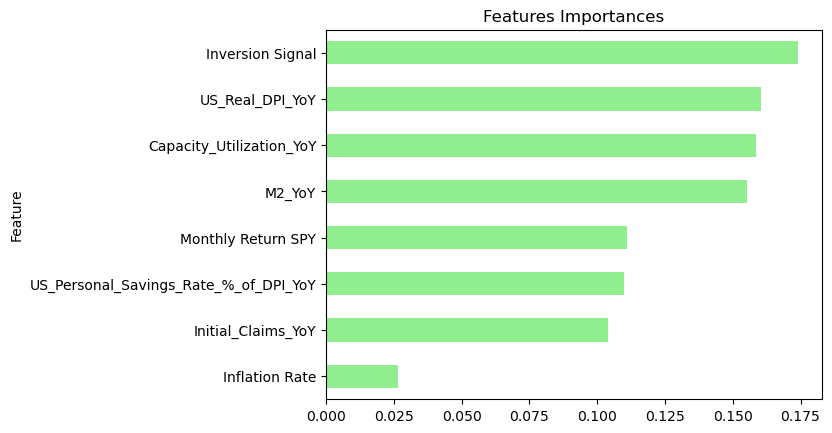

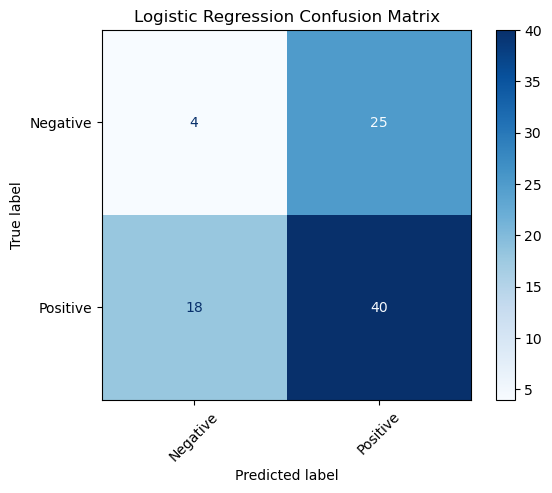

In [63]:
# Make predictions on X-test data:
predictions_logreg = model_logreg.predict(X_test_scaled)

# Display the confusion matrix:

predictions_to_confusion_matrix(y_test, predictions_logreg, "Logistic Regression Confusion Matrix")

In [64]:
print("Test set accuracy: {:.2f}".format(model_logreg.score(X_test_scaled, y_test)))

Test set accuracy: 0.51


In [65]:
# Print the imbalanced classification report
from imblearn.metrics import classification_report_imbalanced
print(classification_report_imbalanced(y_test, predictions_logreg))

                   pre       rec       spe        f1       geo       iba       sup

        0.0       0.18      0.14      0.69      0.16      0.31      0.09        29
        1.0       0.62      0.69      0.14      0.65      0.31      0.10        58

avg / total       0.47      0.51      0.32      0.49      0.31      0.10        87



In [66]:
## The range of values of MCC lie between -1 to +1.
#A model with a score of +1 is a perfect model and -1 is a poor model.
#Similarly to F1 score (Fi score considers TP, FP FN- does not take into account true negative.
#So F1 score is very sensitive to what is called negative but MCC is not
#so MCC actually gives you a better idea of what is going on in your data)

from sklearn.metrics import matthews_corrcoef
matthews_corrcoef(y_test, predictions_logreg)

-0.18698939800169143

In [67]:
model_logreg.intercept_

array([1.14010883])

In [68]:
model_logreg.coef_

array([[-0.20587657,  0.253012  , -0.40498484, -0.34737686,  0.11518363,
        -1.07282618,  1.05917656, -0.00544645,  0.08091018,  0.1806281 ]])

In [69]:
from sklearn.feature_selection import RFECV
selector_logreg  = RFECV(estimator=model_logreg, step=1, cv=5, scoring='accuracy', verbose=1)
selector_logreg = selector_logreg .fit(X_train_scaled, y_train)
selector_logreg.ranking_
selected_logreg = selector_logreg.get_support()

Fitting estimator with 10 features.
Fitting estimator with 9 features.
Fitting estimator with 8 features.
Fitting estimator with 7 features.
Fitting estimator with 6 features.
Fitting estimator with 5 features.
Fitting estimator with 4 features.
Fitting estimator with 3 features.
Fitting estimator with 2 features.
Fitting estimator with 10 features.
Fitting estimator with 9 features.
Fitting estimator with 8 features.
Fitting estimator with 7 features.
Fitting estimator with 6 features.
Fitting estimator with 5 features.
Fitting estimator with 4 features.
Fitting estimator with 3 features.
Fitting estimator with 2 features.
Fitting estimator with 10 features.
Fitting estimator with 9 features.
Fitting estimator with 8 features.
Fitting estimator with 7 features.
Fitting estimator with 6 features.
Fitting estimator with 5 features.
Fitting estimator with 4 features.
Fitting estimator with 3 features.
Fitting estimator with 2 features.
Fitting estimator with 10 features.
Fitting estimato

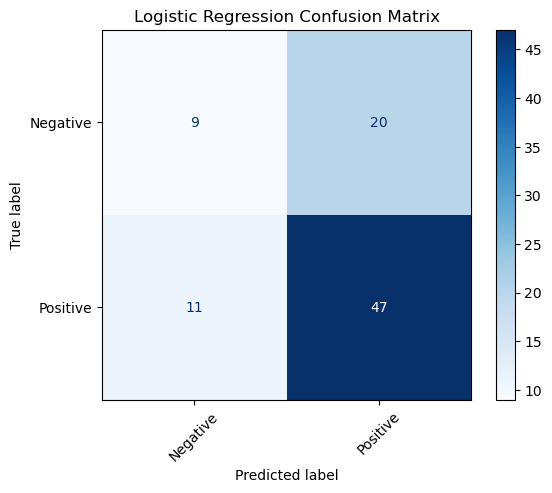

In [70]:
model_logreg = LogisticRegression(solver='lbfgs', random_state=1)
model_logreg.fit(X_train_scaled[:,selected_logreg], y_train)
predictions_logreg = model_logreg.predict(X_test_scaled[:,selected_logreg])

# Display the confusion matrix:

predictions_to_confusion_matrix(y_test, predictions_logreg, "Logistic Regression Confusion Matrix")

In [71]:
print("Test set accuracy: {:.2f}".format(model_logreg.score(X_test_scaled[:,selected_logreg], y_test)))

Test set accuracy: 0.64


In [72]:
print(classification_report_imbalanced(y_test, predictions_logreg))

                   pre       rec       spe        f1       geo       iba       sup

        0.0       0.45      0.31      0.81      0.37      0.50      0.24        29
        1.0       0.70      0.81      0.31      0.75      0.50      0.26        58

avg / total       0.62      0.64      0.48      0.62      0.50      0.26        87



In [73]:
matthews_corrcoef(y_test, predictions_logreg)

0.13521679662509475

What happened to the model quality now. Which features were preserved? What would happen to the Random Forest model, if we used the above feature set?

In [74]:
new_df.drop(columns = 'Monthly Return SPY').columns[selected_logreg]

Index(['Inflation Rate', 'Inversion Signal'], dtype='object')

### Smote Oversampling

In [75]:
# Resample the training data with SMOTE
from collections import Counter
from imblearn.over_sampling import SMOTE


X_resampled_2, y_resampled_2 = SMOTE(random_state=1, sampling_strategy=1.0).fit_resample(
    X_train_scaled, y_train
)

Counter(y_resampled_2)

Counter({0.0: 128, 1.0: 128})

In [94]:
# Train the Logistic Regression model using the resampled data
from sklearn.linear_model import LogisticRegression
model_smote = LogisticRegression(solver='lbfgs', random_state=1)
model_smote.fit(X_resampled_2, y_resampled_2)

LogisticRegression(random_state=1)

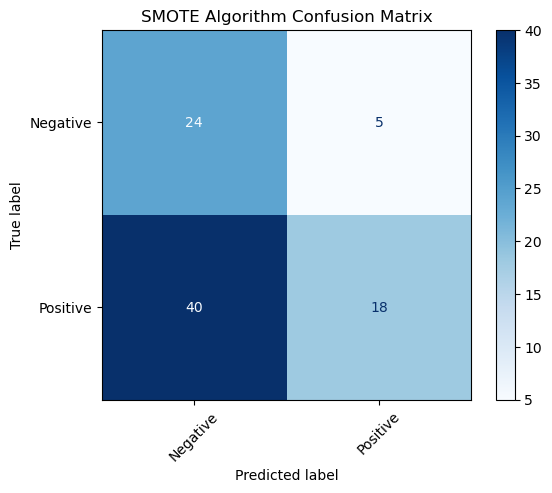

In [95]:
# Make predictions using X-test data:
predictions_smote = model_smote.predict(X_test_scaled)

# Display the confusion matrix

predictions_to_confusion_matrix(y_test, predictions_smote, "SMOTE Algorithm Confusion Matrix")


In [96]:
print("Test set accuracy: {:.2f}".format(model_smote.score(X_test_scaled, y_test)))

Test set accuracy: 0.48


In [97]:
## The range of values of MCC lie between -1 to +1.
#A model with a score of +1 is a perfect model and -1 is a poor model.
#Similarly to F1 score (Fi score considers TP, FP FN- does not take into account true negative.
#So F1 score is very sensitive to what is called negative but MCC is not
#so MCC actually gives you a better idea of what is going on in your data)

from sklearn.metrics import matthews_corrcoef
matthews_corrcoef(y_test, predictions_smote)

0.14744195615489714

In [98]:
selector_smote  = RFECV(estimator=model_smote, step=1, cv=5, scoring='accuracy', verbose=1)
selector_smote = selector_smote.fit(X_train_scaled, y_train)
selector_smote.ranking_
selected_smote = selector_smote.get_support()

Fitting estimator with 10 features.
Fitting estimator with 9 features.
Fitting estimator with 8 features.
Fitting estimator with 7 features.
Fitting estimator with 6 features.
Fitting estimator with 5 features.
Fitting estimator with 4 features.
Fitting estimator with 3 features.
Fitting estimator with 2 features.
Fitting estimator with 10 features.
Fitting estimator with 9 features.
Fitting estimator with 8 features.
Fitting estimator with 7 features.
Fitting estimator with 6 features.
Fitting estimator with 5 features.
Fitting estimator with 4 features.
Fitting estimator with 3 features.
Fitting estimator with 2 features.
Fitting estimator with 10 features.
Fitting estimator with 9 features.
Fitting estimator with 8 features.
Fitting estimator with 7 features.
Fitting estimator with 6 features.
Fitting estimator with 5 features.
Fitting estimator with 4 features.
Fitting estimator with 3 features.
Fitting estimator with 2 features.
Fitting estimator with 10 features.
Fitting estimato

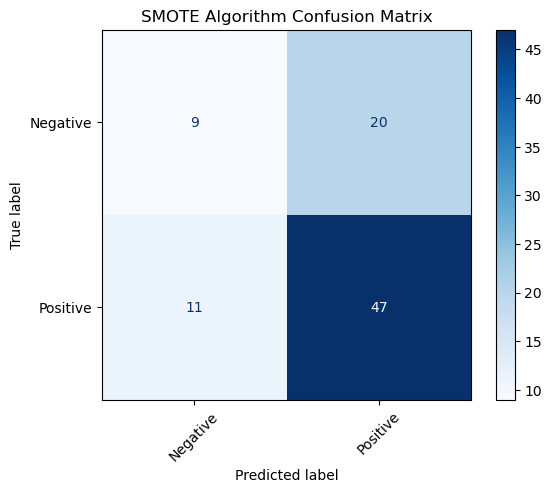

In [99]:
model_smote = LogisticRegression(solver='lbfgs', random_state=1)
model_smote.fit(X_train_scaled[:,selected_smote], y_train)
predictions_smote = model_smote.predict(X_test_scaled[:,selected_smote])

# Display the confusion matrix:

predictions_to_confusion_matrix(y_test, predictions_smote, "SMOTE Algorithm Confusion Matrix")

In [100]:
print("Test set accuracy: {:.2f}".format(model_smote.score(X_test_scaled[:,selected_smote], y_test)))

Test set accuracy: 0.64


What about this case of feature extraction?

### Random Forest (with Oversampling)

In [101]:
# Fit a SKLearn RF model using just the training set (X_train, Y_train):
model_rf_resample = RandomForestClassifier(n_estimators=30, max_depth=3, random_state=0)
model_rf_resample.fit(X_resampled_2, y_resampled_2)

# Make predictions of y values from the x test dataset
predictions_rf_resample = model_rf_resample.predict(X_test_scaled)

# # Assemble actual y data (Y_test) with predicted y data into two columns in a dataframe to compare:
# Results = y_test.to_frame()
#Results["Random Forest Oversampling Predicted Value"] = predictions_rf_resample
##Results

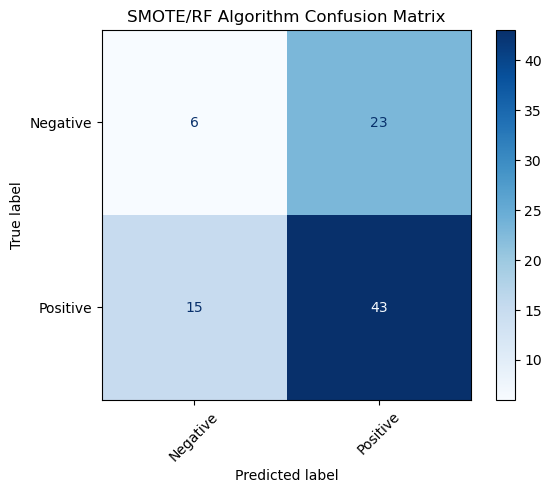

In [77]:
# Display the confusion matrix

predictions_to_confusion_matrix(y_test, predictions_rf_resample, "SMOTE/RF Algorithm Confusion Matrix")

In [103]:
## The range of values of MCC lie between -1 to +1.
#A model with a score of +1 is a perfect model and -1 is a poor model.
#Similarly to F1 score (Fi score considers TP, FP FN- does not take into account true negative.
#So F1 score is very sensitive to what is called negative but MCC is not
#so MCC actually gives you a better idea of what is going on in your data)

from sklearn.metrics import matthews_corrcoef
matthews_corrcoef(y_test, predictions_rf_resample)

-0.05698028822981897

In [104]:
print("Test set accuracy: {:.2f}".format(model_rf_resample.score(X_test_scaled, y_test)))

Test set accuracy: 0.56


In [105]:
# List the features sorted in descending order by feature importance
important_features = model_rf_resample.feature_importances_

sorted(zip(model_rf_resample.feature_importances_, new_df[x_var_list]), reverse=True)

[(0.1998046288414947, 'Capacity_Utilization_YoY'),
 (0.19253748192112088, 'Inflation Rate'),
 (0.12352685732743143, 'US_Real_DPI_YoY'),
 (0.11036890109633675, 'US_Personal_Savings_Rate_%_of_DPI_YoY'),
 (0.10866845749576919, 'M2_YoY'),
 (0.10524300080640403, 'Initial_Claims_YoY'),
 (0.07309928718536467, 'Monthly Return USD'),
 (0.062143551281386, 'Inversion Signal'),
 (0.015092779004300543, 'Industrials Stock Signal'),
 (0.009515055040391799, 'Vol Signal')]

In [106]:
# Visualize the features by their importance to the model
importances_df = pd.DataFrame(sorted(zip(model_rf_resample.feature_importances_, new_df[x_var_list]), reverse=True))
importances_df.set_index(importances_df[1], inplace=True)
importances_df.drop(columns=1, inplace=True)
importances_df.rename(columns={0: 'Feature Importances'}, inplace=True)
importances_sorted = importances_df.sort_values(by='Feature Importances')
importances_sorted.plot(kind='barh', color='lightgreen', title= 'Features Importances', legend=False)

<Axes: title={'center': 'Features Importances'}, ylabel='1'>

### Gradient Boosting

In [110]:
# Choose a learning rate and create classifier
from sklearn.ensemble import GradientBoostingClassifier
classifier_grad = GradientBoostingClassifier(n_estimators=20,
                                        learning_rate=0.63,
                                        max_features=5,
                                        random_state=0)

# Fit the model
classifier_grad.fit(X_train_scaled, y_train.to_numpy())

GradientBoostingClassifier(learning_rate=0.63, max_features=5, n_estimators=20,
                           random_state=0)

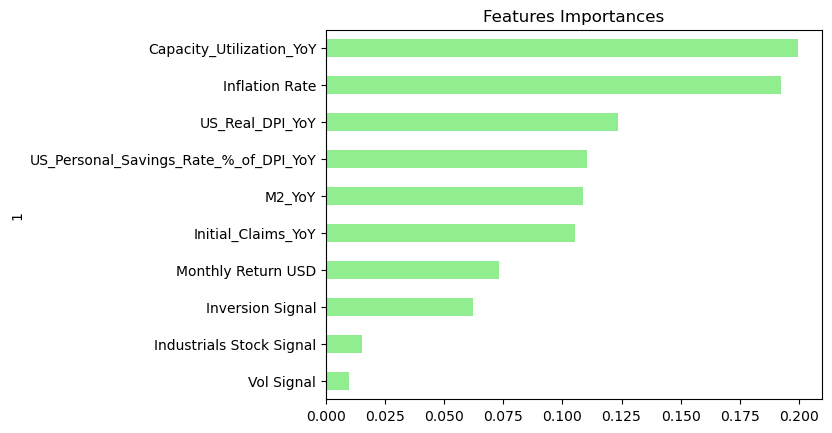

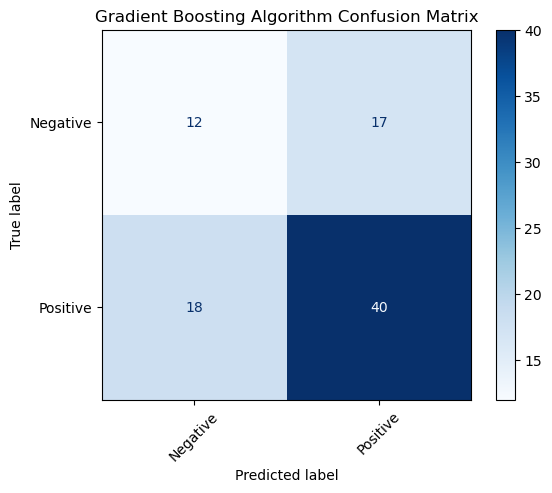

In [111]:
# Make Prediction
predictions_gradient = classifier_grad.predict(X_test_scaled)

# Display confusion matrix

predictions_to_confusion_matrix(y_test, predictions_gradient,"Gradient Boosting Algorithm Confusion Matrix")

In [112]:
print("Test set accuracy: {:.2f}".format(classifier_grad.score(X_test_scaled, y_test)))

Test set accuracy: 0.60


In [113]:
from imblearn.metrics import classification_report_imbalanced
print(classification_report_imbalanced(y_test, predictions_gradient))

                   pre       rec       spe        f1       geo       iba       sup

        0.0       0.40      0.41      0.69      0.41      0.53      0.28        29
        1.0       0.70      0.69      0.41      0.70      0.53      0.29        58

avg / total       0.60      0.60      0.51      0.60      0.53      0.29        87



In [114]:
## The range of values of MCC lie between -1 to +1.
#A model with a score of +1 is a perfect model and -1 is a poor model.
#Similarly to F1 score (Fi score considers TP, FP FN- does not take into account true negative.
#So F1 score is very sensitive to what is called negative but MCC is not
#so MCC actually gives you a better idea of what is going on in your data)

from sklearn.metrics import matthews_corrcoef
matthews_corrcoef(y_test, predictions_gradient)

0.10259783520851541

In [115]:
# Visualize the features by their importance to the model
importances_df = pd.DataFrame(sorted(zip(classifier_grad.feature_importances_, new_df[x_var_list]), reverse=True))
importances_df.set_index(importances_df[1], inplace=True)
importances_df.drop(columns=1, inplace=True)
importances_df.rename(columns={0: 'Feature Importances'}, inplace=True)
importances_sorted = importances_df.sort_values(by='Feature Importances')
importances_sorted.plot(kind='barh', color='lightgreen', title= 'Features Importances', legend=False)

<Axes: title={'center': 'Features Importances'}, ylabel='1'>

In [116]:
selector_grad  = RFECV(estimator=classifier_grad, step=1, cv=5, scoring='accuracy', verbose=1)
selector_smote = selector_grad.fit(X_train_scaled, y_train)
selector_grad.ranking_
selected_grad = selector_grad.get_support()

Fitting estimator with 10 features.
Fitting estimator with 9 features.
Fitting estimator with 8 features.
Fitting estimator with 7 features.
Fitting estimator with 6 features.
Fitting estimator with 5 features.
Fitting estimator with 4 features.
Fitting estimator with 3 features.
Fitting estimator with 2 features.
Fitting estimator with 10 features.
Fitting estimator with 9 features.
Fitting estimator with 8 features.
Fitting estimator with 7 features.
Fitting estimator with 6 features.
Fitting estimator with 5 features.
Fitting estimator with 4 features.
Fitting estimator with 3 features.
Fitting estimator with 2 features.
Fitting estimator with 10 features.
Fitting estimator with 9 features.
Fitting estimator with 8 features.
Fitting estimator with 7 features.
Fitting estimator with 6 features.
Fitting estimator with 5 features.
Fitting estimator with 4 features.
Fitting estimator with 3 features.
Fitting estimator with 2 features.
Fitting estimator with 10 features.
Fitting estimato

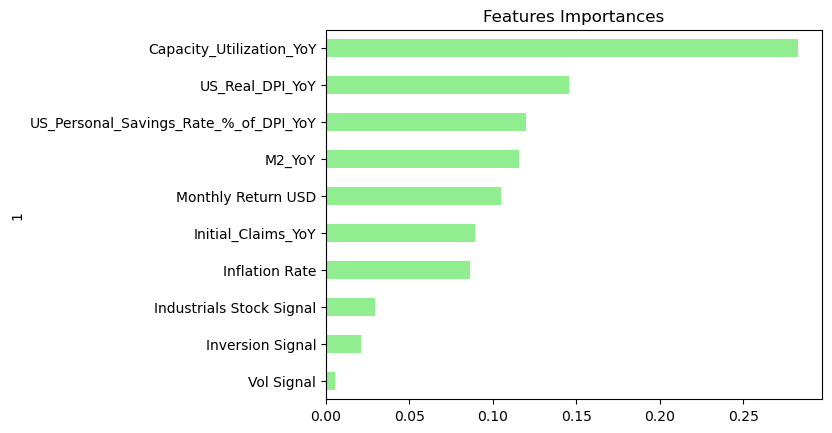

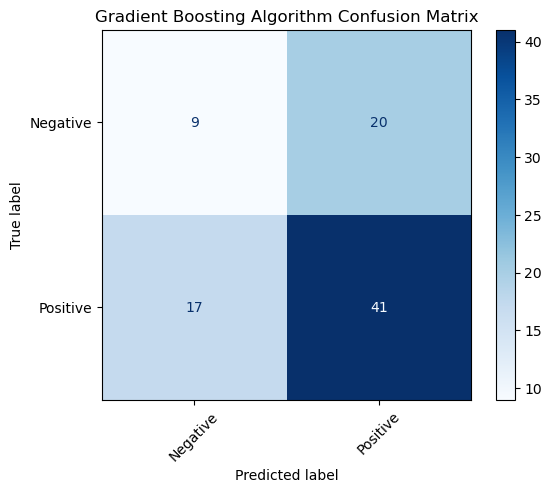

In [117]:
model_grad = LogisticRegression(solver='lbfgs', random_state=1)
model_grad.fit(X_train_scaled[:,selected_grad], y_train)
predictions_grad = model_grad.predict(X_test_scaled[:,selected_grad])

# Display the confusion matrix:

predictions_to_confusion_matrix(y_test, predictions_grad, "Gradient Boosting Algorithm Confusion Matrix")

### Algo Trading Strategy

Here I will build the Algorithmic Trading Strategy using the Machine Learning Models above to inform our buy/sell decisions.
We will focus on just three ML models compile above: (i) Random Forest Model; (ii) SMOTE (Logistic Regression) Model; (iii) Gradient Boosting Classifier Model

In [118]:
# Display the Predicted values for all the Machine Learning Models above:
Results["Percentage Return"] = master_df['Monthly Return SPY']/100
Results["Logistic Regression Predicted Value"] = predictions_logreg
Results["SMOTE Predicted Value"] = predictions_smote
Results["Gradient Boost Predicted Value"] = predictions_gradient
Results["Random Forest Model/Oversampling Predicted Value"] = predictions_rf_resample

Results.head(20)

,Monthly Return SPY,Random Forest Oversampling Predicted Value,Percentage Return,Logistic Regression Predicted Value,SMOTE Predicted Value,Gradient Boost Predicted Value,Random Forest Model/Oversampling Predicted Value
2017-12-31,1.0,1.0,0.012128,1.0,1.0,1.0,1.0
2018-01-31,1.0,1.0,0.056359,1.0,1.0,1.0,1.0
2018-02-28,0.0,1.0,-0.036361,1.0,1.0,1.0,1.0
2018-03-31,0.0,1.0,-0.027411,1.0,1.0,1.0,1.0
2018-04-30,1.0,1.0,0.005168,1.0,1.0,1.0,1.0
2018-05-31,1.0,1.0,0.024309,1.0,1.0,1.0,1.0
2018-06-30,1.0,1.0,0.005751,1.0,1.0,1.0,1.0
2018-07-31,1.0,1.0,0.037046,1.0,1.0,1.0,1.0
2018-08-31,1.0,1.0,0.031920,1.0,1.0,1.0,1.0
2018-09-30,1.0,1.0,0.005946,1.0,1.0,1.0,1.0


In [120]:
def display_pipe(df):
    display(df)

Results = Results.rename(columns={'Random Forest Oversampling Predicted Value': 'Random Forest Predicted Value'})
# Replace predicted values 0 to -1 to account for shorting
Results.replace({'Random Forest Predicted Value': {0: -1}}, inplace=True)
Results["Random Forest Predicted Value"].value_counts().pipe(display_pipe)

Results.replace({'SMOTE Predicted Value': {0: -1}}, inplace=True)
Results["SMOTE Predicted Value"].value_counts().pipe(display_pipe)

Results.replace({'Gradient Boost Predicted Value': {0: -1}}, inplace=True)
Results["Gradient Boost Predicted Value"].value_counts().pipe(display_pipe)

# Results['Logistic Regression Predicted Value'].replace(0, -1, inplace=True)
Results.replace({'Logistic Regression Predicted Value': {0: -1}}, inplace=True)
Results["Logistic Regression Predicted Value"].value_counts().pipe(display_pipe)

# Results['Random Forest Model/Oversampling Predicted Value'].replace(0, -1, inplace=True)
Results.replace({'Random Forest Model/Oversampling Predicted Value': {0: -1}}, inplace=True)
Results["Random Forest Model/Oversampling Predicted Value"].value_counts().pipe(display_pipe)


Results.tail(12)

Random Forest Predicted Value
 1.0    66
-1.0    21
Name: count, dtype: int64

SMOTE Predicted Value
 1.0    67
-1.0    20
Name: count, dtype: int64

Gradient Boost Predicted Value
 1.0    57
-1.0    30
Name: count, dtype: int64

Logistic Regression Predicted Value
 1.0    67
-1.0    20
Name: count, dtype: int64

Random Forest Model/Oversampling Predicted Value
 1.0    66
-1.0    21
Name: count, dtype: int64

,Monthly Return SPY,Random Forest Predicted Value,Percentage Return,Logistic Regression Predicted Value,SMOTE Predicted Value,Gradient Boost Predicted Value,Random Forest Model/Oversampling Predicted Value
2024-03-31,1.0,1.0,0.032702,1.0,1.0,-1.0,1.0
2024-04-30,0.0,-1.0,-0.040320,1.0,1.0,-1.0,-1.0
2024-05-31,1.0,1.0,0.050580,1.0,1.0,1.0,1.0
2024-06-30,1.0,1.0,0.035280,1.0,1.0,1.0,1.0
2024-07-31,1.0,1.0,0.012109,1.0,1.0,1.0,1.0
2024-08-31,1.0,1.0,0.023366,1.0,1.0,1.0,1.0
2024-09-30,1.0,1.0,0.021005,1.0,1.0,1.0,1.0
2024-10-31,0.0,1.0,-0.008924,1.0,1.0,1.0,1.0
2024-11-30,1.0,-1.0,0.059633,1.0,1.0,1.0,-1.0
2024-12-31,0.0,-1.0,-0.024060,1.0,1.0,-1.0,-1.0


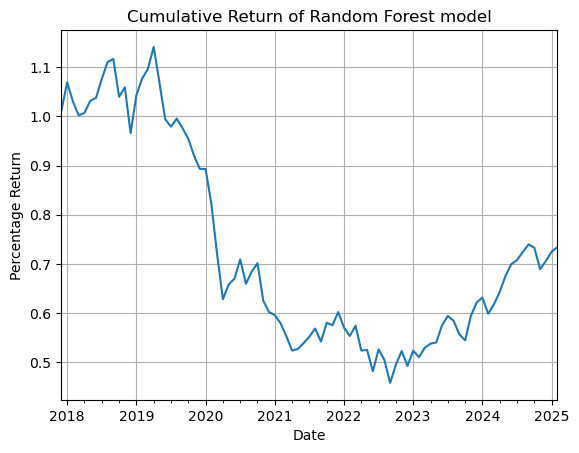

In [121]:
(1 + (Results['Percentage Return'] * Results['Random Forest Predicted Value'])).cumprod().plot()
plt.title('Cumulative Return of Random Forest model')
plt.xlabel('Date')
plt.ylabel('Percentage Return')
plt.grid(True)
plt.show()

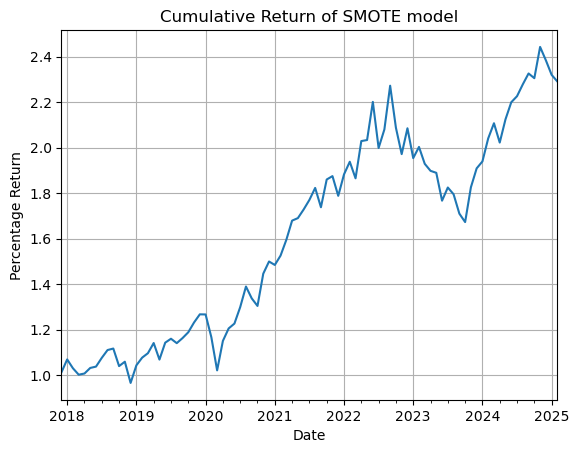

In [122]:
# Calculate cumulative return of SMOTE model and plot the result
(1 + (Results['Percentage Return'] * Results['SMOTE Predicted Value'])).cumprod().plot()
plt.title('Cumulative Return of SMOTE model')
plt.xlabel('Date')
plt.ylabel('Percentage Return')
plt.grid(True)
plt.show()

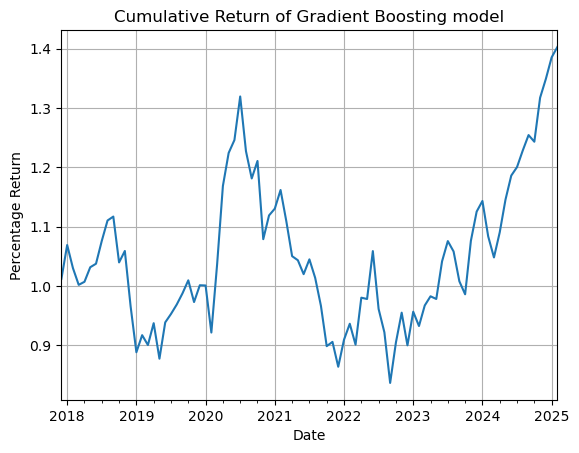

In [123]:
# Calculate cumulative return of Gradient Boosting model and plot the result
(1 + (Results['Percentage Return'] * Results['Gradient Boost Predicted Value'])).cumprod().plot()
plt.title('Cumulative Return of Gradient Boosting model')
plt.xlabel('Date')
plt.ylabel('Percentage Return')
plt.grid(True)
plt.show()

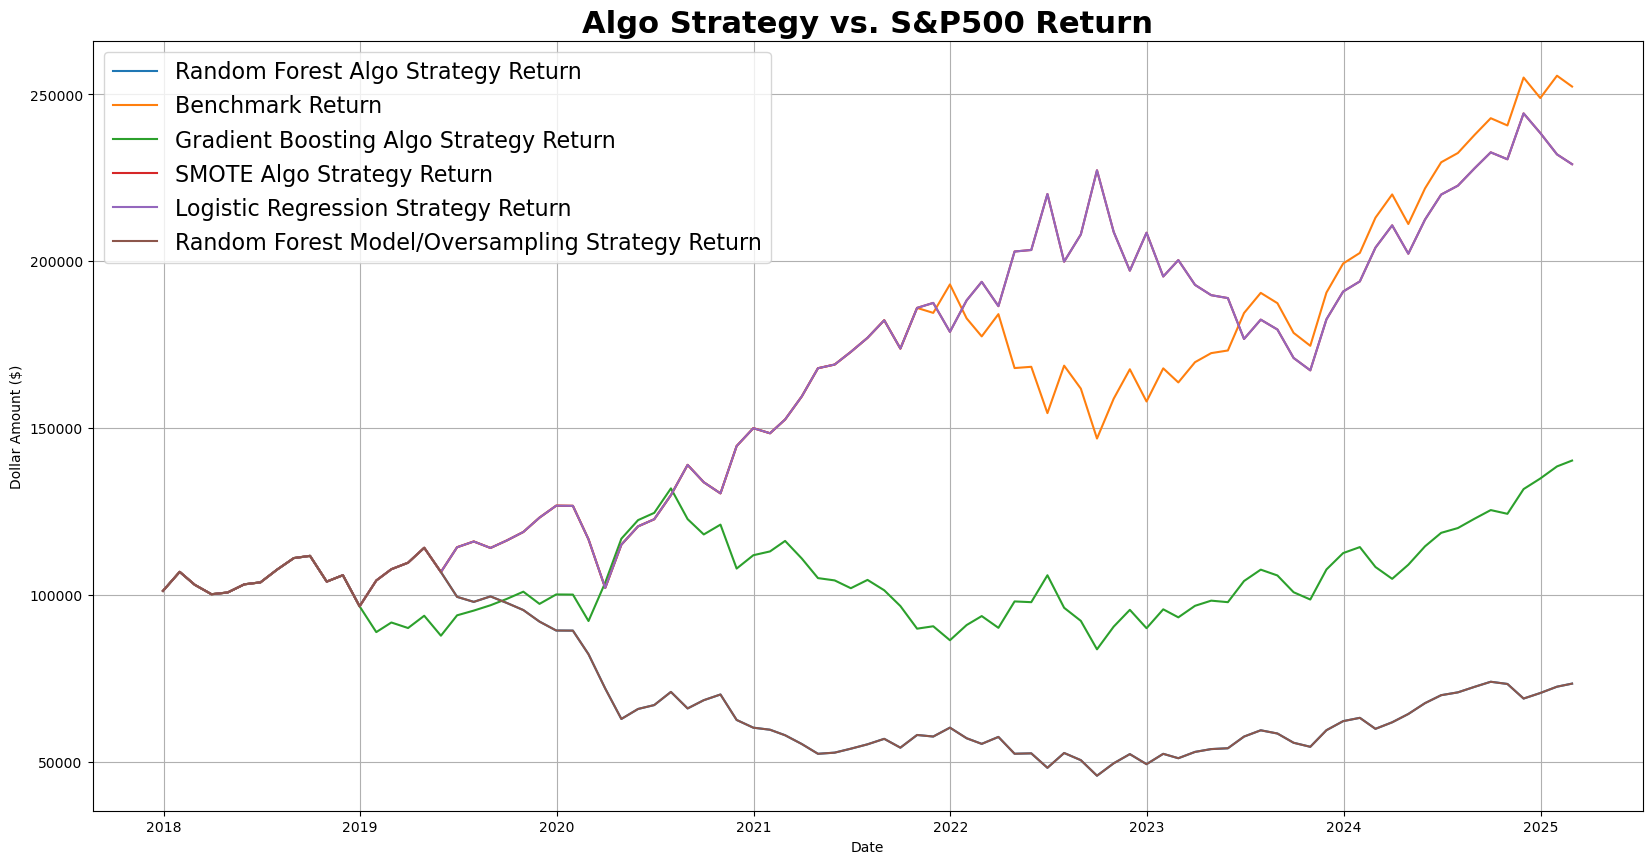

In [124]:
# Set initial capital allocation
initial_capital = 100000

# Define a dictionary with the model names and predicted values columns
models = {
    "Random Forest Algo Strategy Return": Results['Random Forest Predicted Value'],
    "Benchmark Return": 1,  # This is for the benchmark which doesn't use a model
    "Gradient Boosting Algo Strategy Return": Results['Gradient Boost Predicted Value'],
    "SMOTE Algo Strategy Return": Results['SMOTE Predicted Value'],
    "Logistic Regression Strategy Return": Results["Logistic Regression Predicted Value"],
    "Random Forest Model/Oversampling Strategy Return": Results["Random Forest Model/Oversampling Predicted Value"]
    # Add other models here if needed
}

plt.subplots(figsize=(20, 10))

# Loop through the dictionary and plot each cumulative return
for model_name, predicted_values in models.items():
    cumulative_return = initial_capital * (1 + (Results['Percentage Return'] * predicted_values)).cumprod()
    plt.plot(cumulative_return, label=model_name)

plt.legend(prop={'size': 16})
plt.xlabel("Date")
plt.ylabel("Dollar Amount ($)")
plt.title(f"Algo Strategy vs. S&P500 Return", fontweight='bold', fontsize=22)
plt.grid(True)
plt.show()

Here, the color blue corresponds to the training set, red to the testing. Can you see, why the model predictions diverge after a while?

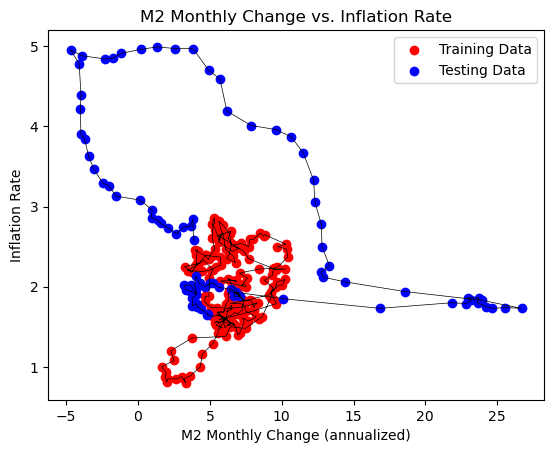

In [125]:
x = new_df['M2_YoY']
y = new_df['Inflation Rate']

training_values = new_df[:cutoff_index]  
testing_values = new_df[cutoff_index:]  

plt.scatter(training_values['M2_YoY'], training_values['Inflation Rate'], color='red')
plt.scatter(testing_values['M2_YoY'], testing_values['Inflation Rate'], color='blue')

new_df_sorted = new_df.sort_index()

plt.plot(new_df_sorted['M2_YoY'], new_df_sorted['Inflation Rate'], color = "black", linewidth = 0.5)
plt.xlabel("M2 Monthly Change (annualized)")
plt.ylabel("Inflation Rate")
plt.title("M2 Monthly Change vs. Inflation Rate")
plt.legend(["Training Data", "Testing Data"])

plt.show()

The above uses just two of the variables. To capture all of the variables, we would need to use PCA. We are using two versions of this, the regular covariance-based one, and the robust (to outliers) one, the Minimum Covariance Determinant method.

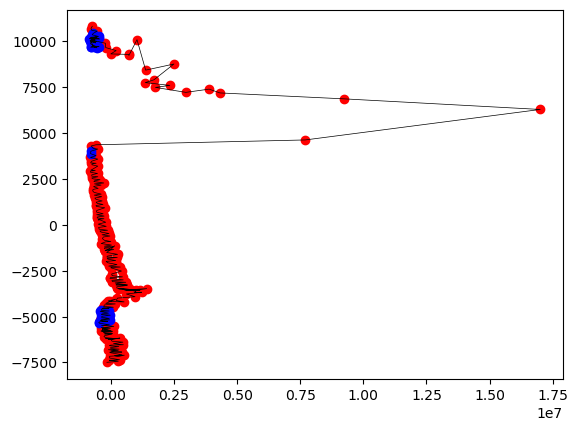

In [127]:
from sklearn.covariance import MinCovDet
from sklearn.decomposition import PCA

master_df_na = master_df.dropna()

pca = PCA(n_components=4)
cov = pca.fit(master_df_na.drop(columns = ['Inversion Signal', 'Vol Signal']))
X = cov.transform(master_df_na.drop(columns = ['Inversion Signal', 'Vol Signal']))

plt.scatter(X[master_df_na['Inversion Signal'] == 0, 0], X[master_df_na['Inversion Signal'] == 0, 1], color ="red")
plt.scatter(X[master_df_na['Inversion Signal'] == 1, 0], X[master_df_na['Inversion Signal'] == 1, 1], color ="blue")

plt.plot(X[:,0], X[:,1], color = "black", linewidth = 0.5)
plt.show()

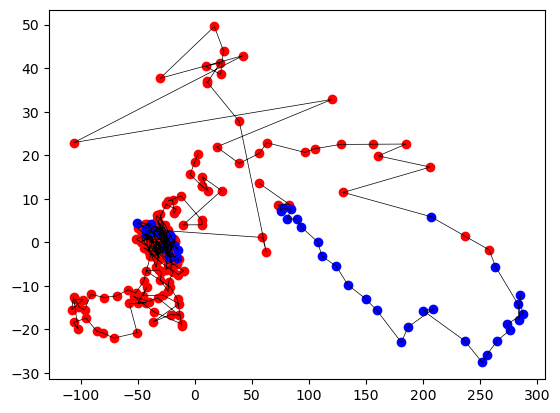

In [128]:
pca = PCA(n_components=4)
mcd = MinCovDet()
robust_cov = mcd.fit(master_df_na.drop(columns = ['Inversion Signal', 'Vol Signal']))
X_robust = np.dot(robust_cov.precision_, (master_df_na.drop(columns = ['Inversion Signal', 'Vol Signal']) - robust_cov.location_).T).T

Xr = pca.fit_transform(X_robust)
#Xr = X_robust
plt.scatter(Xr[master_df_na['Inversion Signal'] == 0, 0], Xr[master_df_na['Inversion Signal'] == 0, 1], color ="red")
plt.scatter(Xr[master_df_na['Inversion Signal'] == 1, 0], Xr[master_df_na['Inversion Signal'] == 1, 1], color ="blue")
plt.plot(Xr[:,0], Xr[:,1], color = "black", linewidth = 0.5)
plt.show()

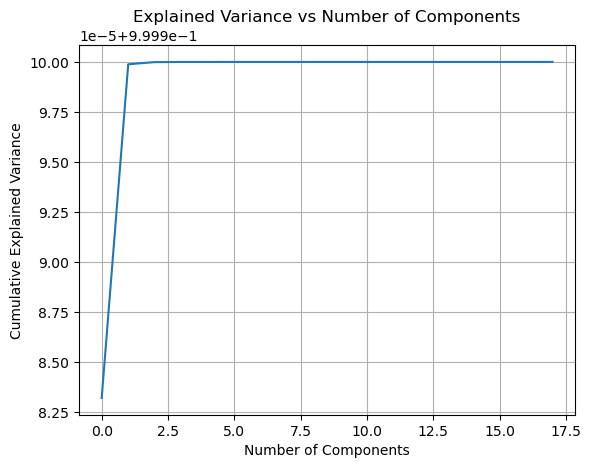

In [129]:
pca = PCA().fit(master_df_na.drop(columns=['Inversion Signal', 'Vol Signal']))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs Number of Components')
plt.grid(True)
plt.show()


**Why is the nonrobust one clearer in the above cases?** Can you determine, how many relevant dimensions do you need to reliabily describe our system. What are the dimensions, and what is their meaning?

Let's add more variables, and use color to distinguish the cases where the SPY return is negative or positive. Again, we use regular and robust PCA.

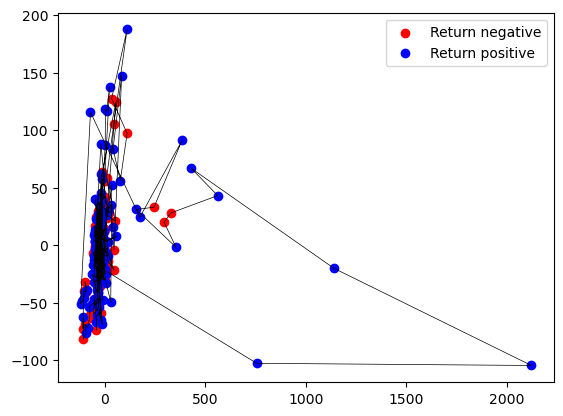

In [130]:
pca1 = PCA(n_components=4)
cov = pca1.fit(new_df.drop(columns = ['Monthly Return SPY', 'Inversion Signal', 'Vol Signal']))
Xa = cov.transform(new_df.drop(columns = ['Monthly Return SPY', 'Inversion Signal', 'Vol Signal']))

plt.scatter(Xa[new_df['Monthly Return SPY'] == 0, 0], Xa[new_df['Monthly Return SPY'] == 0, 1], color ="red")
plt.scatter(Xa[new_df['Monthly Return SPY'] == 1, 0], Xa[new_df['Monthly Return SPY'] == 1, 1], color ="blue")

plt.plot(Xa[:,0], Xa[:,1], color = "black", linewidth = 0.5)
plt.legend(["Return negative", "Return positive"])
plt.show()

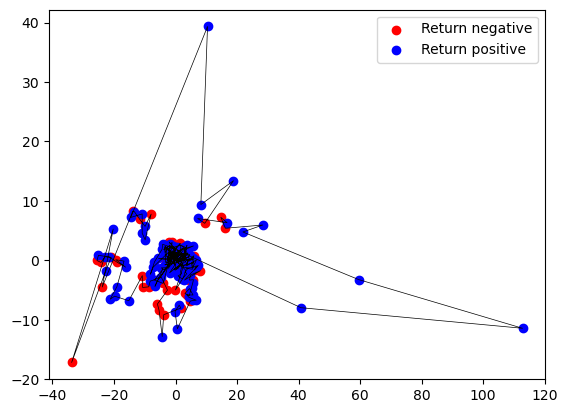

In [131]:
pca3 = PCA(n_components=4)
mcd3 = MinCovDet()
robust_cov3 = mcd.fit(new_df.drop(columns = ['Monthly Return SPY', 'Inversion Signal', 'Vol Signal']))
X_robust3 = np.dot(robust_cov3.precision_, (new_df.drop(columns = ['Monthly Return SPY', 'Inversion Signal', 'Vol Signal']) - robust_cov3.location_).T).T

Xb = pca3.fit_transform(X_robust3)

plt.scatter(Xb[new_df['Monthly Return SPY'] == 0, 0], Xb[new_df['Monthly Return SPY'] == 0, 1], color ="red")
plt.scatter(Xb[new_df['Monthly Return SPY'] == 1, 0], Xb[new_df['Monthly Return SPY'] == 1, 1], color ="blue")
plt.plot(Xb[:,0], Xb[:,1], color = "black", linewidth = 0.5)
plt.legend(["Return negative", "Return positive"])
plt.show()

We'll finally look at sets 'X_train_scaled' and 'X_test_scaled'. 

In [132]:
X_train_scaled.shape

(202, 10)

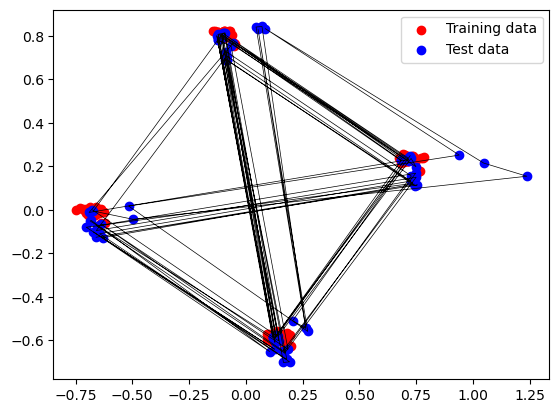

In [133]:
pca4 = PCA(n_components=4)
cov4 = pca4.fit(X_train_scaled)
Xc_train = cov4.transform(X_train_scaled)
Xc_test = cov4.transform(X_test_scaled)

plt.scatter(Xc_train[:, 0], Xc_train[:, 1], color ="red")
plt.scatter(Xc_test[:, 0], Xc_test[:, 1], color ="blue")

#plt.plot(Xc_train[:,0], Xc_train[:,1], color = "black", linewidth = 0.5)
plt.plot(Xc_test[:,0], Xc_test[:,1], color = "black", linewidth = 0.5)
plt.legend(["Training data", "Test data"])
plt.show()

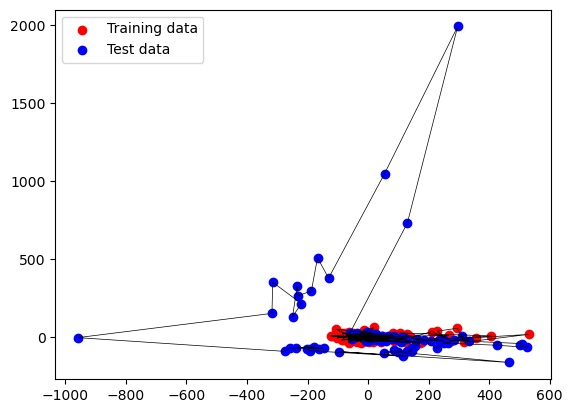

In [134]:
pca5 = PCA(n_components=4)
mcd5 = MinCovDet()
robust_cov5 = mcd.fit(X_train_scaled)
X_r5_train  = np.dot(robust_cov5.precision_, (X_train_scaled - robust_cov5.location_).T).T
X_r5_test   = np.dot(robust_cov5.precision_, (X_test_scaled - robust_cov5.location_).T).T

cov5 = pca5.fit(X_r5_train)

Xd_train = cov5.transform(X_r5_train)
Xd_test  = cov5.transform(X_r5_test)

plt.scatter(Xd_train[:, 0], Xd_train[:, 1], color ="red")
plt.scatter(Xd_test[:, 0], Xd_test[:, 1], color ="blue")

plt.plot(Xd_train[:,0], Xd_train[:,1], color = "black", linewidth = 0.5)
plt.plot(Xd_test[:,0], Xd_test[:,1], color = "black", linewidth = 0.5)
plt.legend(["Training data", "Test data"])
plt.show()

Compare the training and testing data sets. How do these compare to each other? How would you model the data in a lower-dimensional version?

### Further analysis

Take the datasets downloaded in this document, and create your own combination of variables. Especially, incorporate the full variables of the indeces, not just the 0/1-indicators we created above. Use PCA and Robust-PCA to visualize your findings.

Why does the feature selection improve (often greatly) the logistic regression, but not the Random Forest classifier?